# 用于手写数字识别的多分类神经网络

在本练习中，你将使用神经网络识别手写数字 0-9。


# 大纲
- [ 1 - 软件包 ](#1)
- [ 2 - ReLU 激活函数](#2)
- [ 3 - Softmax 函数](#3)
  - [ 练习 1](#ex01)
- [ 4 - 神经网络](#4)
  - [ 4.1 问题陈述](#4.1)
  - [ 4.2 数据集](#4.2)
  - [ 4.3 模型表示](#4.3)
  - [ 4.4 TensorFlow 模型实现](#4.4)
  - [ 4.5 Softmax 的放置位置](#4.5)
    - [ 练习 2](#ex02)

<a name="1"></a>
## 1 - 软件包

首先运行下面的单元格，导入本作业期间需要的所有软件包。
- [numpy](https://numpy.org/) 是使用 Python 进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org) 是一个常用的 Python 绘图库。
- [tensorflow](https://www.tensorflow.org/) 是一个常用的机器学习平台。

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import * 

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

<a name="2"></a>
## 2 - ReLU 激活
本周介绍了一种新的激活函数——修正线性单元（ReLU）。
$$ a = max(0,z) \quad\quad\text {# ReLU function} $$

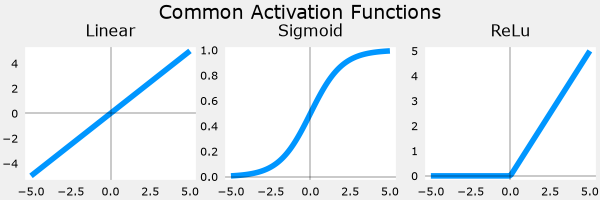

In [2]:
plt_act_trio()

<img align="right" src="./images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
右侧课程中的示例展示了 ReLU 的一种应用。在这个示例中，派生出的“认知度”特征不是二元特征，而是在连续范围内取值。Sigmoid 最适合开/关或二元情形，而 ReLU 提供连续的线性关系。此外，它还有一个输出为零的“关闭”区间。
这种“关闭”特性使 ReLU 成为非线性激活函数。为什么需要它？这使多个单元可以共同对结果函数做出贡献，而不会相互干扰。配套的可选实验会对此做进一步探讨。

<a name="3"></a>
## 3 - Softmax 函数
多分类神经网络会生成 N 个输出，并选择其中一个作为预测答案。在输出层中，线性函数会生成一个向量 $\mathbf{z}$，并将其输入 softmax 函数。Softmax 函数按如下所述将 $\mathbf{z}$ 转换为概率分布。应用 softmax 后，每个输出都将介于 0 和 1 之间，且所有输出之和为 1。它们可以解释为概率。Softmax 的输入越大，对应的输出概率也越大。
<center>  <img  src="./images/C2_W2_NNSoftmax.PNG" width="600" />  

softmax 函数可以写为：
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

其中，$z = \mathbf{w} \cdot \mathbf{x} + b$，N 是输出层中的特征/类别数。

<a name="ex01"></a>
### 练习 1
让我们创建一个 NumPy 实现：

In [3]:
# UNQ_C1
# GRADED CELL: my_softmax

def my_softmax(z):  
    """ Softmax converts a vector of values to a probability distribution.
    Args:
      z (ndarray (N,))  : input data, N features
    Returns:
      a (ndarray (N,))  : softmax of z
    """    
    ### START CODE HERE ### 
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):
        ez_sum += np.exp(z[k])
    for j in range(N):
        a[j] = np.exp(z[j]) / ez_sum
    ### END CODE HERE ### 
    return a

In [4]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BEGIN UNIT TEST  
test_my_softmax(my_softmax)
# END UNIT TEST  

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]
 All tests passed.


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    一种实现方式是：先用一个 for 循环构建分母，再用第二个循环计算各个输出。
    
```python
def my_softmax(z):  
    N = len(z)
    a =                     # initialize a to zeros 
    ez_sum =                # initialize sum to zero
    for k in range(N):      # loop over number of outputs             
        ez_sum +=           # sum exp(z[k]) to build the shared denominator      
    for j in range(N):      # loop over number of outputs again                
        a[j] =              # divide each the exp of each output by the denominator   
    return(a)
```
<details>
  <summary><font size="3" color="darkgreen"><b>点击查看代码</b></font></summary>
   
```python
def my_softmax(z):  
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):                
        ez_sum += np.exp(z[k])       
    for j in range(N):                
        a[j] = np.exp(z[j])/ez_sum   
    return(a)

Or, a vector implementation:

def my_softmax(z):  
    ez = np.exp(z)              
    a = ez/np.sum(ez)           
    return(a)

```

在下方改变 `z` 输入的值。特别注意分子中的指数如何放大数值间的微小差异。还要注意输出值之和为一。

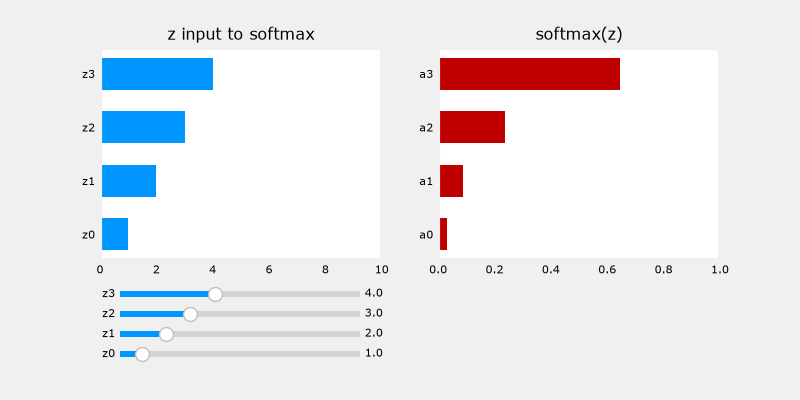

In [5]:
plt.close("all")
plt_softmax(my_softmax)

<a name="4"></a>
## 4 - 神经网络

在上周的作业中，你实现了一个用于二分类的神经网络。本周，你将把它扩展到多分类。这将使用 softmax 激活函数。


<a name="4.1"></a>
### 4.1 问题陈述

在本练习中，你将使用神经网络识别十个手写数字 0-9。这是一个从 n 个选项中选择一个的多分类任务。如今，自动手写数字识别已被广泛使用，例如识别邮件信封上的邮政编码，以及识别银行支票上填写的金额。


<a name="4.2"></a>
### 4.2 数据集

首先，你将加载此任务的数据集。
- 下面所示的 `load_data()` 函数会将数据加载到变量 `X` 和 `y` 中


- 该数据集包含 5000 个手写数字训练样本 $^1$。

    - 每个训练样本都是一个 20 像素 x 20 像素的数字灰度图像。
        - 每个像素由一个浮点数表示，指示该位置的灰度强度。
        - 20 x 20 的像素网格被“展开”为一个 400 维向量。
        - 每个训练样本成为数据矩阵 `X` 中的一行。
        - 这样便得到一个 5000 x 400 的矩阵 `X`，其中每一行都是一个手写数字图像训练样本。

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- 训练集的第二部分是一个 5000 x 1 维向量 `y`，其中包含训练集的标签
    - 如果图像是数字 `0`，则 `y = 0`；如果图像是数字 `4`，则 `y = 4`；依此类推。

$^1$<sub> 这是 MNIST 手写数字数据集的一个子集（http://yann.lecun.com/exdb/mnist/）</sub>

In [6]:
# load dataset
X, y = load_data()

#### 4.2.1 查看变量
让我们进一步熟悉您的数据集。  
- 一个很好的起点是打印每个变量，看看其中包含什么。

下面的代码会打印变量 `X` 和 `y` 中的第一个元素。  

In [7]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-0

In [8]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


#### 4.2.2 检查变量的维度

另一种熟悉数据的方法是查看其维度。请打印 `X` 和 `y` 的形状，看看数据集中有多少个训练样本。

In [9]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


#### 4.2.3 数据可视化

首先，你将对训练集的一个子集进行可视化。
- 在下面的单元格中，代码会从 `X` 中随机选择 64 行，将每一行还原为一幅 20 像素×20 像素的灰度图像，并将这些图像一起显示。
- 每幅图像的标签显示在图像上方

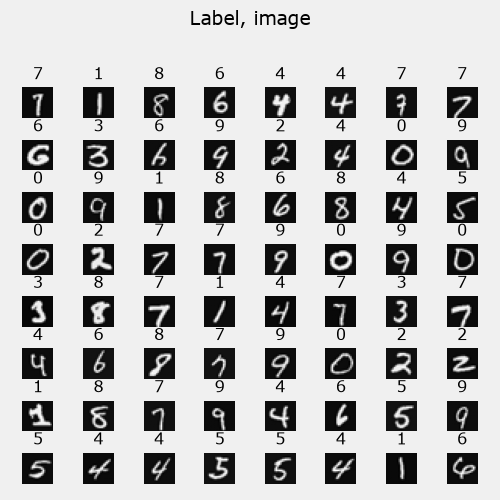

In [13]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

#fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()
fig.suptitle("Label, image", fontsize=14)
fig.tight_layout(
    pad=0.13,
    rect=[0, 0.03, 1, 0.91]
)

plt.show()

<a name="4.3"></a>
### 4.3 模型表示

本作业中使用的神经网络如下图所示。
- 它包含两个采用 ReLU 激活函数的密集层，之后是一个采用线性激活函数的输出层。
    - 回顾一下，我们的输入是数字图像的像素值。
    - 由于图像大小为 $20\times20$，因此共有 $400$ 个输入
    
<img src="images/C2_W2_Assigment_NN.png" width="600" height="450">

- 这些参数的维度适用于如下神经网络：第 1 层有 $25$ 个单元，第 2 层有 $15$ 个单元，第 3 层有 $10$ 个输出单元，每个数字对应一个输出单元。

    - 回顾一下，这些参数的维度按以下方式确定：
        - 如果网络某一层有 $s_{in}$ 个单元，下一层有 $s_{out}$ 个单元，那么
            - $W$ 的维度将为 $s_{in} \times s_{out}$。
            - $b$ 将是一个包含 $s_{out}$ 个元素的向量。
  
    - 因此，`W` 和 `b` 的形状为：
        - 第 1 层：`W1` 的形状是 (400, 25)，`b1` 的形状是 (25,)
        - 第 2 层：`W2` 的形状是 (25, 15)，`b2` 的形状是 (15,)
        - 第 3 层：`W3` 的形状是 (15, 10)，`b3` 的形状是 (10,)
>**注意：** 偏置向量 `b` 可以表示为一维数组 (n,) 或二维数组 (n,1)。TensorFlow 使用一维表示，本实验也将沿用这一约定：
               

<a name="4.4"></a>
### 4.4 TensorFlow 模型实现

TensorFlow 模型是逐层构建的。系统会为您计算某一层的输入维度（上面的 $s_{in}$）。您需要指定该层的*输出维度*，它会决定下一层的输入维度。第一层的输入维度由下面 `model.fit` 语句中指定的输入数据大小推导得出。
>**注意：** 也可以添加一个输入层来指定第一层的输入维度。例如：  
`tf.keras.Input(shape=(400,)),    #specify input shape`  
为了更清楚地说明模型尺寸，我们将在这里包含该输入层。

<a name="4.5"></a>
### 4.5 Softmax 的放置位置
如课程和可选 softmax 实验中所述，训练时将 softmax 与损失函数组合，而不是将 softmax 放在输出层，可以提高数值稳定性。这会影响模型的*构建*和*使用*。  
构建模型：  
* 最后一个全连接层应使用“linear”激活，实际上等同于不使用激活函数。
* `model.compile` 语句将通过包含 `from_logits=True` 来表明这一点。
`loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) `  
* 这不会影响目标值的形式。对于 SparseCategorialCrossentropy，目标值是预期的数字 0–9。

使用模型：
* 输出不是概率。如果需要输出概率，请应用 softmax 函数。

<a name="ex02"></a>
### 练习 2

下面，使用 Keras 的[顺序模型](https://keras.io/guides/sequential_model/)和带 ReLU 激活函数的[密集层](https://keras.io/api/layers/core_layers/dense/)，构建上述三层网络。

In [36]:
# UNQ_C2
# GRADED CELL: Sequential model
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),
        Dense(25, activation='relu', name = "L1"),
        Dense(15, activation='relu', name = "L2"),
        Dense(10, activation='linear', name = "L3"),
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [37]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 25)                  │          10,025 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L2 (Dense)                           │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L3 (Dense)                           │ (None, 10)                  │             160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
_ = model(tf.keras.Input(shape=(400,)))

In [39]:
print(model.input)
print(model.input.shape)
print(len(model.layers))

<KerasTensor shape=(None, 400), dtype=float32, sparse=False, ragged=False, name=keras_tensor_23>
(None, 400)
3


<details>
  <summary><font size="3" color="darkgreen"><b>预期输出（点击展开）</b></font></summary>
`model.summary()` 函数会显示有用的模型摘要。请注意，除非指定名称，否则层名称由系统自动生成，因此可能有所不同。    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 25)                10025     
_________________________________________________________________
L2 (Dense)                   (None, 15)                390       
_________________________________________________________________
L3 (Dense)                   (None, 10)                160       
=================================================================
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________
```

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
```python
tf.random.set_seed(1234)
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),     # @REPLACE 
        Dense(25, activation='relu', name = "L1"), # @REPLACE 
        Dense(15, activation='relu',  name = "L2"), # @REPLACE  
        Dense(10, activation='linear', name = "L3"),  # @REPLACE 
        ### END CODE HERE ### 
    ], name = "my_model" 
)
```

In [40]:
# BEGIN UNIT TEST     
test_model(model, 10, 400)
# END UNIT TEST     

AttributeError: 'tuple' object has no attribute 'as_list'

摘要中显示的参数数量，对应于下面所示权重数组和偏置数组中的元素数量。

让我们进一步检查权重，以验证 TensorFlow 生成的维度是否与上面的计算相同。

In [27]:
[layer1, layer2, layer3] = model.layers

In [28]:
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


**预期输出**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (10,)
```

以下代码：
* 定义损失函数 `SparseCategoricalCrossentropy`，并通过添加 `from_logits=True` 指明应将 softmax 纳入损失计算；
* 定义优化器。常用选择是课程中介绍过的自适应矩估计（Adam）。

In [29]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X,y,
    epochs=40
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6978
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8310
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5314
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4139
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3501
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3088
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2773
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2523
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2314
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2138
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1987
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1850
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1726
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1614
Epoch 15/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

#### 轮次与批次
在上面的 `compile` 语句中，`epochs` 的数量设置为 100。这表示训练时应将整个数据集应用 100 次。训练期间，会看到如下所示的进度输出：
```
Epoch 1/100
157/157 [==============================] - 0s 1ms/step - loss: 2.2770
```
第一行 `Epoch 1/100` 描述模型当前正在运行哪个轮次。为提高效率，训练数据集会被拆分成“批次”。TensorFlow 中批次的默认大小为 32。我们的数据集中有 5000 个样本，即大约 157 个批次。第二行的记号 `157/157 [====` 描述已经执行了哪个批次。

#### 损失（代价）
在课程 1 中，我们学习了如何通过监控代价来跟踪梯度下降的进展。理想情况下，代价会随着算法迭代次数的增加而下降。TensorFlow 将代价称为 `loss`。在上面执行 `model.fit` 时，你已经看到每个轮次都会显示损失。[.fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model) 方法会返回包括损失在内的多种指标，这些指标已存入上面的 `history` 变量。可以使用它绘制如下损失图，以便检查损失情况。

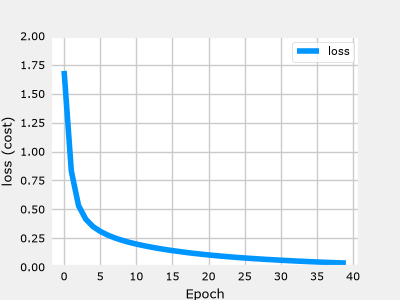

In [30]:
plot_loss_tf(history)

#### 预测
要进行预测，请使用 Keras 的 `predict`。下面的 X[1015] 包含数字 2 的图像。

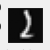

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
 predicting a Two: 
[[-4.67  0.68  3.71 -2.23 -0.45 -1.39 -0.59 -5.69 -2.06 -3.49]]
 Largest Prediction index: 2


In [31]:
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

最大的输出是 prediction[2]，表明预测的数字是“2”。如果问题只要求做出选择，这就足够了。使用 NumPy 的 [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 进行选择。如果问题要求概率，则需要 softmax：

In [32]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[2.10e-04 4.42e-02 9.17e-01 2.41e-03 1.44e-02 5.60e-03 1.25e-02 7.57e-05
  2.87e-03 6.86e-04]]
Total of predictions: 1.000


要返回表示预测目标的整数，需要取得最大概率对应的索引。这可以使用 NumPy 的 [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 函数完成。

In [33]:
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


让我们比较随机抽取的 64 个数字的预测值与标签。运行需要一些时间。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

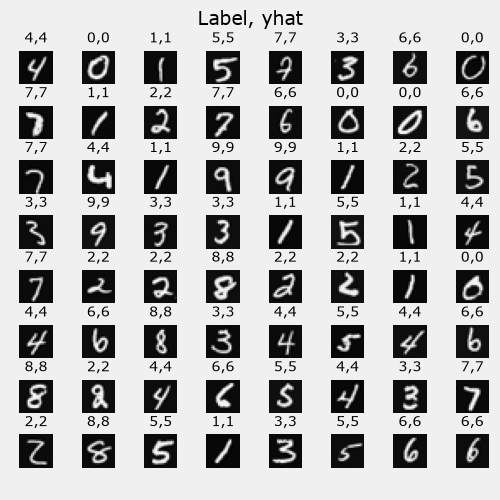

In [34]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()

让我们看看其中的一些错误。
>注意：增加训练轮数可以消除此数据集上的错误。

In [35]:
print( f"{display_errors(model,X,y)} errors out of {len(X)} images")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
24 errors out of 5000 images


### 恭喜！
你已经成功构建并使用神经网络完成多分类。